## Turma: DADOS - 2025.2

## Materia: RNA e Deep Learning

### Nome: Wagner Ferreira Porto de Vasconcelos

# Regressão Linear com PyTorch - kc_house_data.csv

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [214]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [215]:
#!/bin/bash
# !curl -L -o /content/housesalesprediction.zip\y
# https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

In [216]:
# !unzip /content/housesalesprediction.zip

In [217]:
# Load the dataset
df = pd.read_csv('kc_house_data.csv')

df = df.drop(['id', 'date'], axis=1)

X = df.drop('price', axis=1)
y = df[['price']].values.reshape(-1,1)

In [218]:

df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [219]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

### Normalização dos dados

In [220]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [221]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 18])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 18])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [222]:
model = torch.nn.Linear(18, 1)

### Verificando a inicialização dos parâmetros

In [223]:
model.weight.data

tensor([[-0.2220, -0.0462, -0.1132, -0.0629, -0.2082,  0.0946, -0.2113, -0.0150,
          0.0819, -0.0794,  0.1337,  0.0297,  0.1296,  0.1512, -0.1041,  0.0857,
         -0.1020,  0.0739]])

### Testando o predict da rede

In [224]:
model(torch.ones(5,18))

tensor([[-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072]], grad_fn=<AddmmBackward0>)

In [225]:
model(X_train_tensor[:3])

tensor([[-0.8767],
        [ 0.1813],
        [-0.6099]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [226]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

### Laço de treinamento

In [227]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [228]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [229]:
num_epochs = 120
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/120], Train Loss: 0.296107, Val Loss: 0.326401
Epoch[40/120], Train Loss: 0.291559, Val Loss: 0.322062
Epoch[60/120], Train Loss: 0.291300, Val Loss: 0.321875
Epoch[80/120], Train Loss: 0.291279, Val Loss: 0.321892
Epoch[100/120], Train Loss: 0.291276, Val Loss: 0.321909
Epoch[120/120], Train Loss: 0.291276, Val Loss: 0.321917


## Avaliação

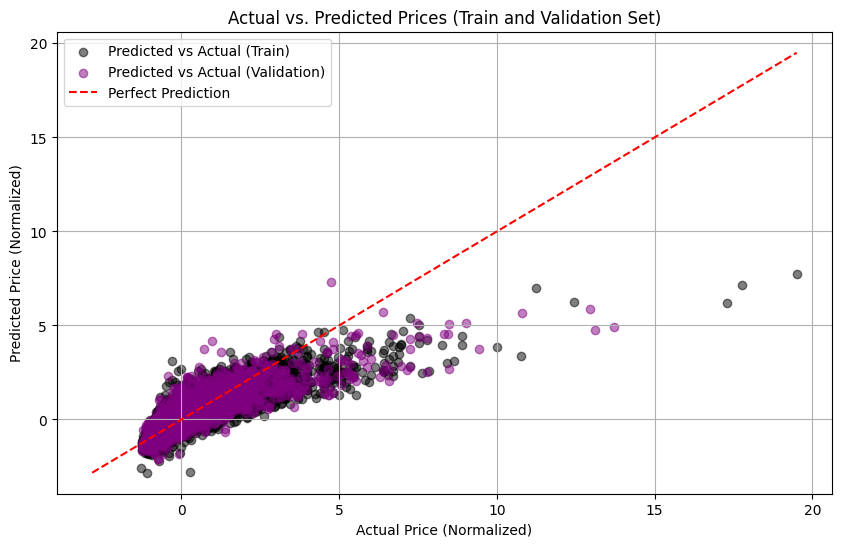

In [233]:

y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Plot predicted vs actual for Training Data
plt.scatter(y_train_tensor.numpy(), y_pred_train.data.numpy(), alpha=0.5, label='Predicted vs Actual (Train)', color='black')

# Plot predicted vs actual for Validation Data
plt.scatter(y_val_tensor.numpy(), y_pred_val.data.numpy(), alpha=0.5, label='Predicted vs Actual (Validation)', color='purple')

# Plot a perfect prediction line (y=x)
max_val = max(y_val_tensor.max(), y_pred_val.max(), y_train_tensor.max(), y_pred_train.max()).item()
min_val = min(y_val_tensor.min(), y_pred_val.min(), y_train_tensor.min(), y_pred_train.min()).item()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price (Normalized)')
plt.ylabel('Predicted Price (Normalized)')
plt.title('Actual vs. Predicted Prices (Train and Validation Set)')
plt.legend()
plt.grid(True)
plt.show()

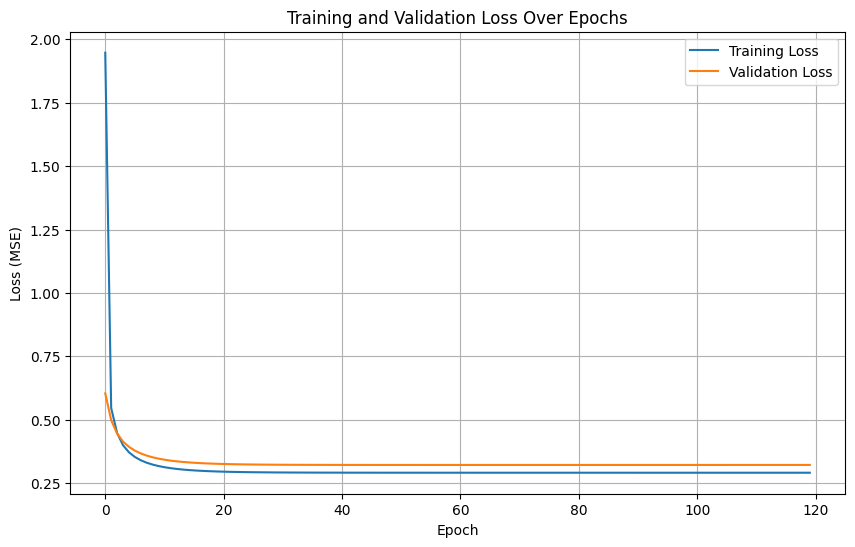

In [231]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()